# Function Transformer

In [28]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.linear_model import LogisticRegression


In [29]:
df=pd.read_csv(r"C:\Users\sus\Downloads\train.csv", usecols=['Age','Fare','Survived'])

In [30]:
df

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
...,...,...,...
886,0,27.0,13.0000
887,1,19.0,30.0000
888,0,NaN,23.4500
889,1,26.0,30.0000


In [31]:
df.isnull().sum()

Survived      0
Age         177
Fare          0
dtype: int64

In [32]:
df["Age"].fillna(df["Age"].mean(),inplace=True)

C:\Users\sus\AppData\Local\Temp\ipykernel_13216\2595122914.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean(),inplace=True)


In [33]:
df.isnull().sum()

Survived    0
Age         0
Fare        0
dtype: int64

In [34]:
x=df.iloc[:,1:3]
y=df.iloc[:,0]

In [35]:
x_train, x_test, y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

C:\Users\sus\AppData\Local\Temp\ipykernel_13216\4286096501.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train["Age"])


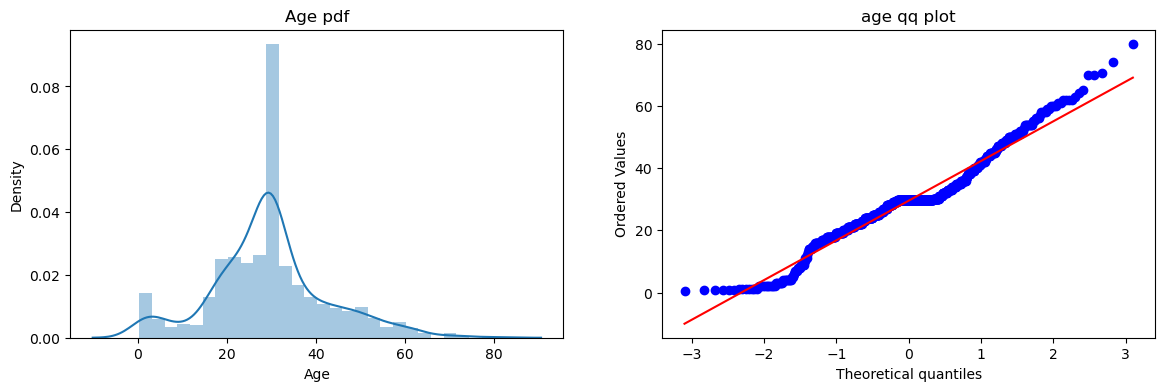

In [36]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_train["Age"])
plt.title("Age pdf")
plt.subplot(122)
stats.probplot(x_train["Age"],dist="norm",plot=plt)
plt.title("age qq plot")
plt.show()

C:\Users\sus\AppData\Local\Temp\ipykernel_13216\3440864991.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_train["Fare"])


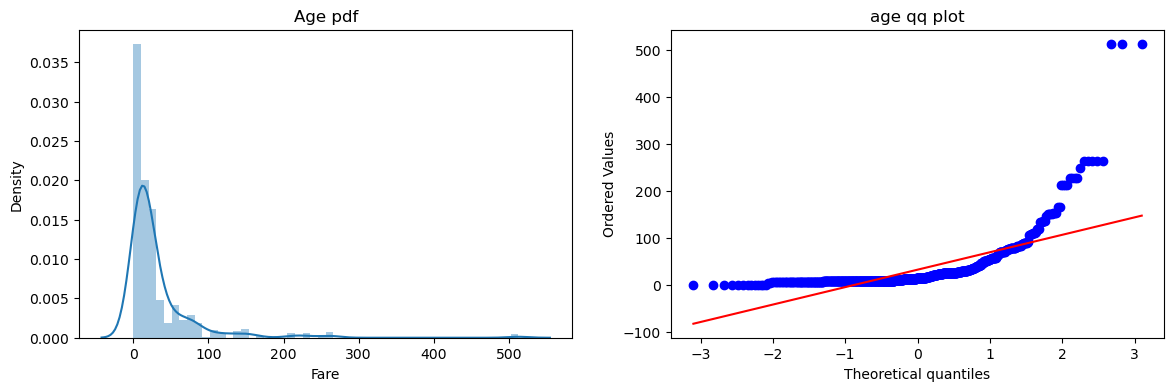

In [37]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(x_train["Fare"])
plt.title("Age pdf")
plt.subplot(122)
stats.probplot(x_train["Fare"],dist="norm",plot=plt)
plt.title("age qq plot")
plt.show()

In [38]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [39]:
clf.fit(x_train,y_train)
clf2.fit(x_train,y_train)

DecisionTreeClassifier()

In [40]:
y_pred=clf.predict(x_test)
y_pred1=clf2.predict(x_test)

In [41]:
print("accuracy lr",accuracy_score(y_pred,y_test))
print("accuracy dt",accuracy_score(y_pred1,y_test))

accuracy lr 0.6480446927374302
accuracy dt 0.6480446927374302


In [42]:
trf=FunctionTransformer(func=np.log1p) 
x_train_transformed=trf.fit_transform(x_train)
x_test_transformed=trf.transform(x_test)

In [43]:
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [44]:
clf.fit(x_train_transformed,y_train)
clf2.fit(x_train_transformed,y_train)

DecisionTreeClassifier()

In [45]:
y_pred=clf.predict(x_test_transformed)
y_pred1=clf2.predict(x_test_transformed)

In [46]:
print("accuracy lr",accuracy_score(y_pred,y_test))
print("accuracy dt",accuracy_score(y_pred1,y_test))

accuracy lr 0.6815642458100558
accuracy dt 0.6703910614525139


In [47]:
# conclusion : decision tree algo is not affed by the distribustion of data
#improvment in logistic regression

In [48]:
#cross val
x_transformed=trf.fit_transform(x)
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [49]:

print("lr", np.mean(cross_val_score(clf,x_transformed,y,scoring="accuracy",cv=10)))
print("dt", np.mean(cross_val_score(clf2,x_transformed,y,scoring="accuracy",cv=10)))

lr 0.678027465667915
dt 0.656629213483146


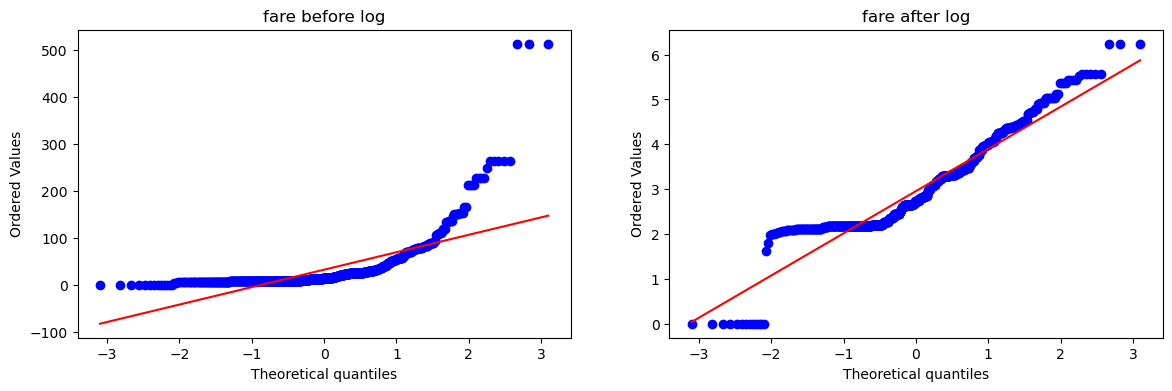

In [50]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(x_train["Fare"],dist="norm",plot=plt)
plt.title("fare before log")
plt.subplot(122)
stats.probplot(x_train_transformed["Fare"],dist="norm",plot=plt)
plt.title("fare after log")
plt.show()


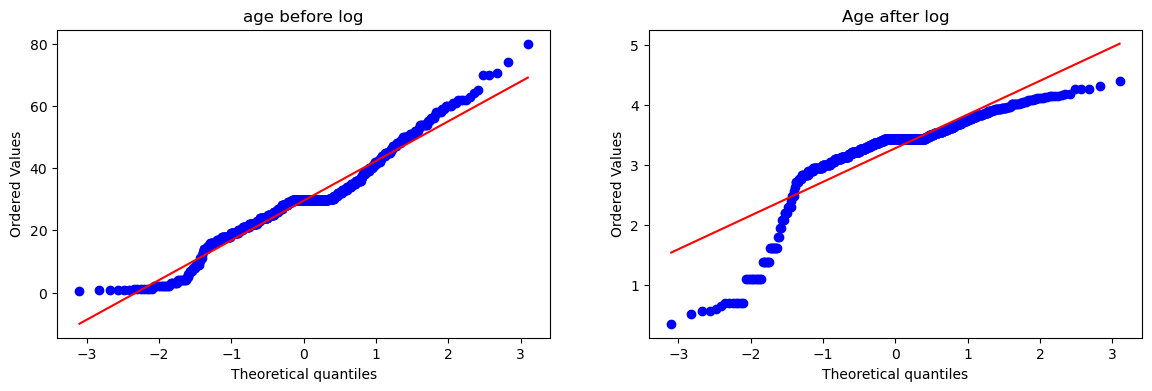

In [51]:
plt.figure(figsize=(14,4))
plt.subplot(121)
stats.probplot(x_train["Age"],dist="norm",plot=plt)
plt.title("age before log")
plt.subplot(122)
stats.probplot(x_train_transformed["Age"],dist="norm",plot=plt)
plt.title("Age after log")
plt.show()


In [52]:
# AS AGE  was not right skewed and we applied the log transform , thats why the distribuition of age deviated from noraml distribution 

In [53]:
trf2=ColumnTransformer([("log",FunctionTransformer(np.log1p),["Fare"])],remainder="passthrough")

In [59]:
x_transformed2=trf2.fit_transform(x_train)
x_test_transformed2=trf2.transform(x_test)
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

clf.fit(x_transformed2,y_train)
clf2.fit(x_transformed2,y_train)

DecisionTreeClassifier()

In [60]:
y_pred=clf.predict(x_test_transformed2)
y_pred=clf2.predict(x_test_transformed2)

In [68]:
print("accuracy lr",accuracy_score(y_test,y_pred))
print("accuracy dt",accuracy_score(y_test,y_pred))

accuracy lr 0.6703910614525139
accuracy dt 0.6703910614525139


In [69]:
x_transformed2=trf2.fit_transform(x)
clf=LogisticRegression()
clf2=DecisionTreeClassifier()

In [70]:

print("dr",np.mean(cross_val_score(clf2,x_transformed2,y,scoring="accuracy", cv=10)))
print("lr",np.mean(cross_val_score(clf,x_transformed2,y,scoring="accuracy",cv=10)))

dr 0.6577028714107365
lr 0.6712609238451936


In [71]:
def apply_transform(transform):
    x=df.iloc[:,1:3]
    y=df.iloc[:,0]

    trf=ColumnTransformer([("log",FunctionTransformer(transform),["Fare"])],remainder="passthrough")
    x_trans=trf.fit_transform(x)
    clf=LogisticRegression()
    print("accuracy ", np.mean(cross_val_score(clf,x_trans,y,scoring="accuracy",cv=10)))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    stats.probplot(x["Fare"],dist="norm",plot=plt)
    plt.title("fare before transform")
    plt.subplot(122)
    stats.probplot(x_trans[:,0],dist="norm",plot=plt)
    plt.title("fare after transform")


    plt.show()
    

accuracy  0.6589013732833957


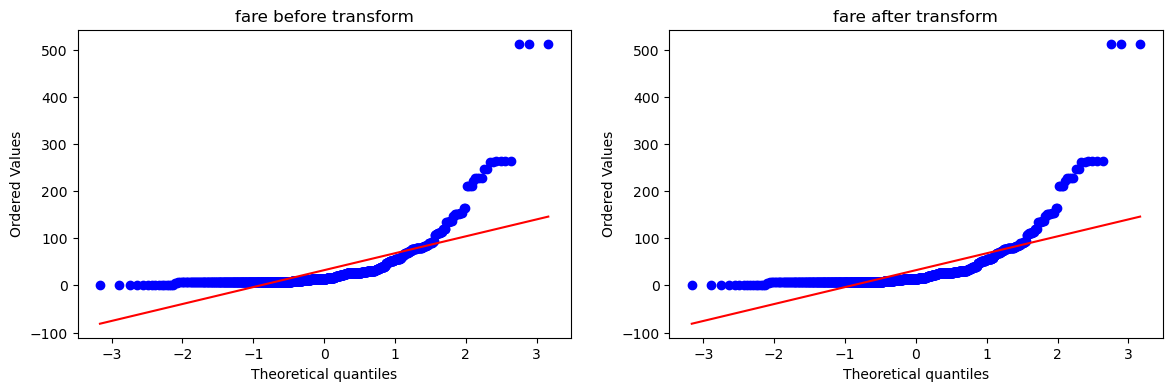

In [72]:
apply_transform(lambda x:x)

accuracy  0.6431335830212235


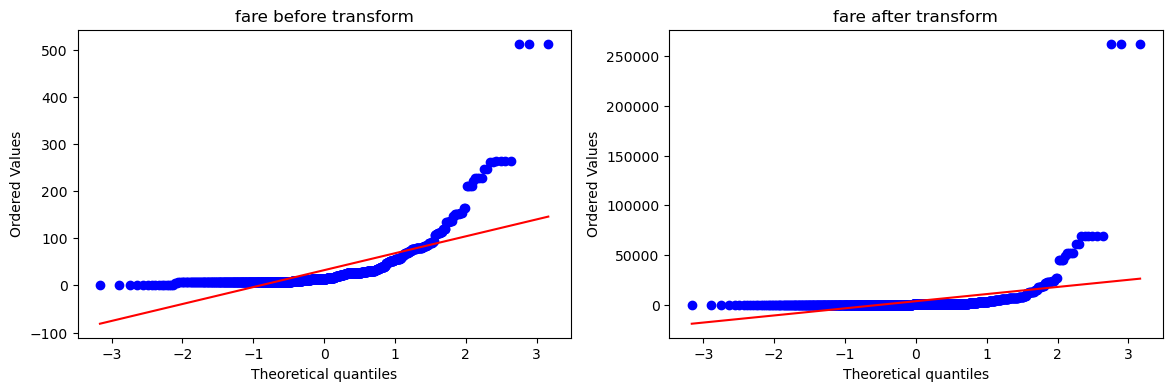

accuracy  0.6712609238451936


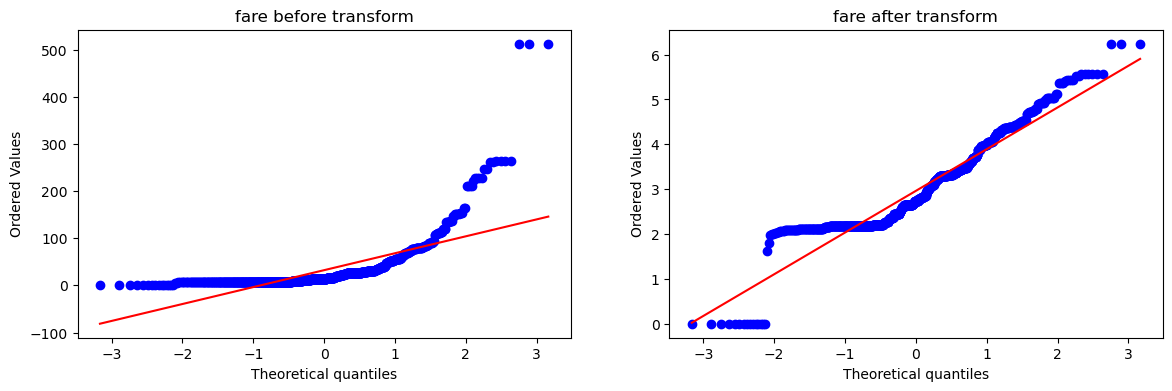

accuracy  0.6611485642946316


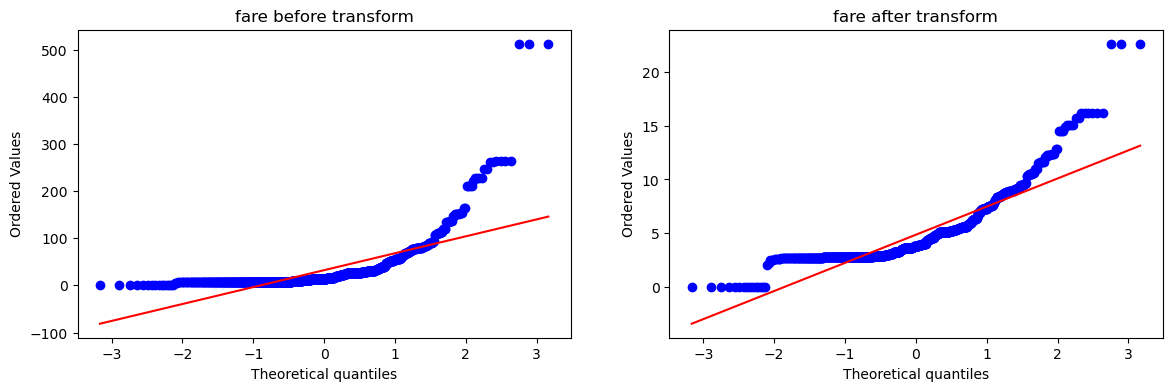

In [73]:
apply_transform(lambda x:x**2)     
apply_transform(np.log1p)      # log(1+x) transform
apply_transform(np.sqrt) 

accuracy  0.61729088639201


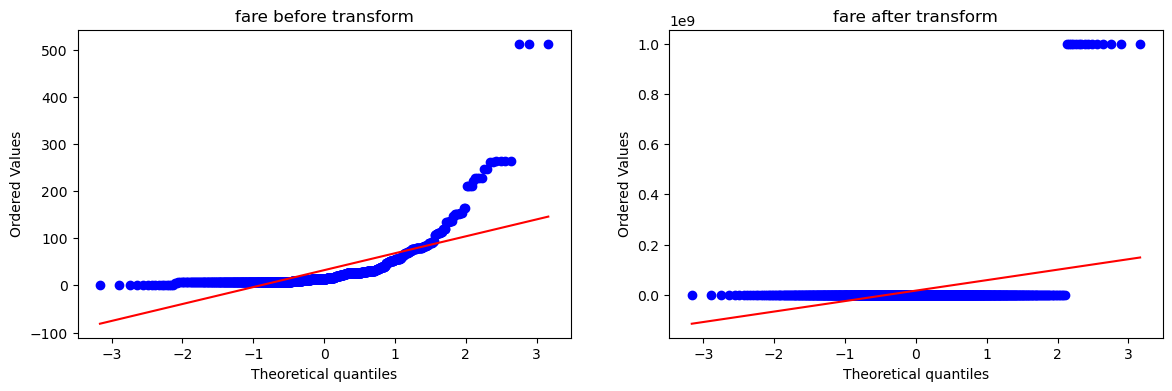

In [74]:
apply_transform(lambda x:1/(x+0.000000001) )    


accuracy  0.6195131086142323


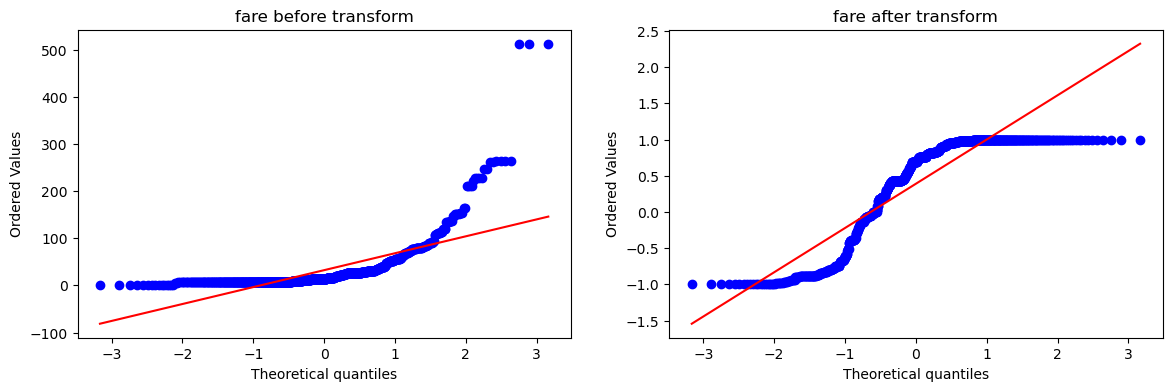

In [75]:
apply_transform(np.sin )    
